In [1]:
# =============================================================================
# CARIACO SEDIMENT TRAP DATA PROCESSING
# =============================================================================
# Source: BCO-DMO CARIACO sediment trap dataset
# Output: Monthly aggregated flux data compatible with CARIACO_EnvData pipeline
# Units:  mmol N m-2 d-1, mmol C m-2 d-1
# =============================================================================

library(tidyverse)

# =============================================================================
# 1. READ AND CLEAN
# =============================================================================

ds <- read.csv("BCO-DMO/Sediment_Trap.csv", na.strings = c("nd", "?", ""))

ds$date <- as.Date(as.character(ds$date_open), format = "%Y%m%d")

flux_cols <- c("MF_Total", "MF_Corg", "MF_CaCO3", "MF_Sibio", "MF_Terr", "MF_N")
ds <- ds %>%
  mutate(across(all_of(flux_cols), as.numeric))

cat("=== Raw dataset ===\n")
cat(sprintf("Rows: %d\n", nrow(ds)))
cat(sprintf("Date range: %s to %s\n", min(ds$date, na.rm = TRUE), max(ds$date, na.rm = TRUE)))
cat(sprintf("Trap depths: %s m\n", paste(sort(unique(ds$depth_trap)), collapse = ", ")))

# =============================================================================
# 2. UNIT CONVERSION
# =============================================================================

MW_N <- 14.007  # g/mol
MW_C <- 12.011  # g/mol

trap_data <- ds %>%
  mutate(
    MF_N_mmol = MF_N * 1000 / MW_N,
    MF_Corg_mmol = MF_Corg * 1000 / MW_C,
    CN_ratio = ifelse(MF_N_mmol > 0 & !is.na(MF_N_mmol),
                      MF_Corg_mmol / MF_N_mmol,
                      NA_real_),
    # Match format used in merge script: MM-YYYY
    time_month = format(date, format = "%m-%Y"),
    year = as.numeric(format(date, "%Y")),
    month = as.numeric(format(date, "%m"))
  )

# =============================================================================
# 3. DIAGNOSTIC: SAMPLING STRUCTURE
# =============================================================================

cat("\n=== SAMPLING DIAGNOSTICS ===\n")

# 3a. Collection duration statistics
cat("\n--- Collection duration (days) ---\n")
trap_data %>%
  group_by(depth_trap) %>%
  summarise(
    mean_duration = round(mean(duration_d, na.rm = TRUE), 1),
    sd_duration = round(sd(duration_d, na.rm = TRUE), 1),
    min_duration = min(duration_d, na.rm = TRUE),
    max_duration = max(duration_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  print()

# 3b. Samples per calendar month (at each depth)
samples_per_month <- trap_data %>%
  filter(!is.na(MF_N_mmol)) %>%
  group_by(depth_trap, time_month) %>%
  summarise(
    n_samples = n(),
    total_duration = sum(duration_d, na.rm = TRUE),
    .groups = "drop"
  )

cat("\n--- Distribution of samples per calendar month ---\n")
samples_per_month %>%
  group_by(depth_trap, n_samples) %>%
  summarise(n_months = n(), .groups = "drop") %>%
  pivot_wider(names_from = n_samples, values_from = n_months, 
              names_prefix = "n_samp_", values_fill = 0) %>%
  print()

# 3c. Check for months with unusual total coverage
cat("\n--- Monthly coverage diagnostics (225m trap) ---\n")
coverage_225 <- samples_per_month %>%
  filter(depth_trap == 225) %>%
  mutate(
    days_in_month = 30,  # approximate
    coverage_ratio = total_duration / days_in_month
  )

cat(sprintf("Months with < 20 days total coverage: %d / %d\n",
            sum(coverage_225$total_duration < 20),
            nrow(coverage_225)))
cat(sprintf("Months with > 40 days total coverage: %d / %d\n",
            sum(coverage_225$total_duration > 40),
            nrow(coverage_225)))

# 3d. Show problematic months (if any)
problematic <- coverage_225 %>%
  filter(total_duration < 14 | total_duration > 45)

if (nrow(problematic) > 0) {
  cat("\n--- Months with unusual coverage (225m) ---\n")
  print(problematic)
}

# 3e. Compare simple mean vs duration-weighted mean
cat("\n--- Effect of duration-weighting (225m) ---\n")
weighting_comparison <- trap_data %>%
  filter(depth_trap == 225, !is.na(MF_N_mmol)) %>%
  group_by(time_month) %>%
  summarise(
    simple_mean = mean(MF_N_mmol, na.rm = TRUE),
    weighted_mean = weighted.mean(MF_N_mmol, duration_d, na.rm = TRUE),
    n_samples = n(),
    .groups = "drop"
  ) %>%
  mutate(pct_diff = 100 * (weighted_mean - simple_mean) / simple_mean)

cat(sprintf("Mean absolute %% difference (weighted vs simple): %.2f%%\n",
            mean(abs(weighting_comparison$pct_diff), na.rm = TRUE)))
cat(sprintf("Max absolute %% difference: %.2f%%\n",
            max(abs(weighting_comparison$pct_diff), na.rm = TRUE)))

# Show months where weighting matters most
cat("\n--- Months where weighting differs most (>5%%) ---\n")
weighting_comparison %>%
  filter(abs(pct_diff) > 5) %>%
  arrange(desc(abs(pct_diff))) %>%
  print(n = 10)

# =============================================================================
# 4. MONTHLY AGGREGATION (duration-weighted)
# =============================================================================

# Using duration-weighted means to account for variable collection periods
trap_monthly <- trap_data %>%
  group_by(time_month, depth_trap) %>%
  summarise(
    # Duration-weighted flux means
    MF_N_mmol = weighted.mean(MF_N_mmol, duration_d, na.rm = TRUE),
    MF_Corg_mmol = weighted.mean(MF_Corg_mmol, duration_d, na.rm = TRUE),
    CN_ratio = weighted.mean(CN_ratio, duration_d, na.rm = TRUE),
    MF_Total = weighted.mean(MF_Total, duration_d, na.rm = TRUE),
    
    # Metadata
    n_samples = sum(!is.na(MF_N_mmol)),
    total_duration_d = sum(duration_d, na.rm = TRUE),
    
    .groups = "drop"
  ) %>%
  # Handle NaN from empty groups

  mutate(across(where(is.numeric), ~ifelse(is.nan(.), NA_real_, .)))

cat("\n=== Monthly aggregation complete ===\n")
cat(sprintf("Total month-depth combinations: %d\n", nrow(trap_monthly)))

# =============================================================================
# 5. PIVOT TO WIDE FORMAT FOR MERGE
# =============================================================================

# Create wide format with depth as suffix (matches your pipeline style)
trap_monthly_wide <- trap_monthly %>%
  pivot_wider(
    id_cols = time_month,
    names_from = depth_trap,
    values_from = c(MF_N_mmol, MF_Corg_mmol, CN_ratio, n_samples),
    names_glue = "{.value}_{depth_trap}m"
  )

cat(sprintf("\n=== Wide format: %d months, %d columns ===\n", 
            nrow(trap_monthly_wide), ncol(trap_monthly_wide)))

# =============================================================================
# 6. FINAL SUMMARY
# =============================================================================

cat("\n=== Flux summary by depth (mmol N m-2 d-1) ===\n")
trap_monthly %>%
  filter(!is.na(MF_N_mmol)) %>%
  group_by(depth_trap) %>%
  summarise(
    n_months = n(),
    mean = round(mean(MF_N_mmol), 3),
    sd = round(sd(MF_N_mmol), 3),
    median = round(median(MF_N_mmol), 3),
    .groups = "drop"
  ) %>%
  print()

# =============================================================================
# 7. SAVE
# =============================================================================


# Long format (all depths, monthly)
saveRDS(trap_monthly, "processed/SedTrap_monthly.rds")

# Wide format (ready for merge script)
saveRDS(trap_monthly_wide, "processed/SedTrap_monthly_wide.rds")
write.csv(trap_monthly_wide, "processed/SedTrap_monthly_wide.csv", row.names = FALSE)

# Also save sample-level for reference
saveRDS(trap_data, "processed/SedTrap_samples.rds")

cat("\n=== Saved ===\n")
cat("  processed/SedTrap_samples.rds      (sample-level)\n")
cat("  processed/SedTrap_monthly.rds      (monthly, long format)\n")
cat("  processed/SedTrap_monthly_wide.rds (monthly, wide format for merge)\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


=== Raw dataset ===
Rows: 1573
Date range: 1995-11-08 to 2010-10-29
Trap depths: 152, 225, 410, 810, 1210 m

=== SAMPLING DIAGNOSTICS ===

--- Collection duration (days) ---
# A tibble: 5 × 5
  depth_trap mean_duration sd_duration min_duration max_duration
       <int>         <dbl>       <dbl>        <int>        <int>
1        152          13.4         1.9            6           18
2        225          13.3         2.1            6           18
3        410          13.3         2.1            6           18
4        810          13.3         2.1            6           18
5       1210          13.3         2.1            6           18

--- Distribution of samples per calendar month ---
# A tibble: 5 × 6
  depth_trap n_samp_1 n_samp_2 n_samp_3 n_samp_4 n_samp_5
       <int>    <int>    <int>    <int>    <int>    <int>
1        152        9       52       11        0        0
2        225       11      102       23        2        1
3        410       12      107       23        2   

In [10]:
# =============================================================================
# SEDIMENT TRAP DATA PROCESSING
# Source: BCO-DMO CARIACO sediment trap dataset
# Target: 152m trap nitrogen flux for model validation
# =============================================================================

library(tidyverse)

# =============================================================================
# 1. READ AND CLEAN
# =============================================================================

ds <- read.csv("BCO-DMO/Sediment_Trap.csv", na.strings = c("nd", "?", ""))

# Parse date from integer YYYYMMDD
ds$date <- as.Date(as.character(ds$date_open), format = "%Y%m%d")

# Convert flux columns from character to numeric
flux_cols <- c("MF_Total", "MF_Corg", "MF_CaCO3", "MF_Sibio", "MF_Terr", "MF_N")
ds <- ds %>%
  mutate(across(all_of(flux_cols), as.numeric))

cat("=== Raw dataset ===\n")
cat(sprintf("Rows: %d, Date range: %s to %s\n", nrow(ds), min(ds$date, na.rm=T), max(ds$date, na.rm=T)))
cat(sprintf("Trap depths: %s m\n", paste(sort(unique(ds$depth_trap)), collapse = ", ")))
cat(sprintf("Trap IDs: %s\n", paste(unique(ds$trap_ID), collapse = ", ")))

# =============================================================================
# 2. CHECK COVERAGE BY TRAP DEPTH
# =============================================================================

coverage <- ds %>%
  group_by(depth_trap) %>%
  summarise(
    n = n(),
    date_min = min(date, na.rm = TRUE),
    date_max = max(date, na.rm = TRUE),
    pct_na_MF_N = round(100 * sum(is.na(MF_N)) / n(), 1),
    pct_na_MF_Corg = round(100 * sum(is.na(MF_Corg)) / n(), 1),
    .groups = "drop"
  )

cat("\n=== Coverage by trap depth ===\n")
print(coverage)

# =============================================================================
# 3. FILTER TO 152m TRAP (standard depth for model comparison)
# =============================================================================

trap_152 <- ds %>%
  filter(depth_trap == 152) %>%
  select(date, trap_ID, duration_d, MF_Total, MF_Corg, MF_N)

cat(sprintf("\n=== 152m trap: %d samples ===\n", nrow(trap_152)))

# =============================================================================
# 3. FILTER TO SHALLOW TRAPS (152m and 225m)
# =============================================================================

trap_shallow <- ds %>%
  filter(depth_trap %in% c(152, 225)) %>%
  select(date, depth_trap, trap_ID, duration_d, MF_Total, MF_Corg, MF_N)

cat(sprintf("\n=== Shallow traps ===\n"))
cat(sprintf("  152m samples: %d\n", sum(trap_shallow$depth_trap == 152)))
cat(sprintf("  225m samples: %d\n", sum(trap_shallow$depth_trap == 225)))

# =============================================================================
# 4. UNIT CONVERSION
# =============================================================================

MW_N <- 14.007  # g/mol

trap_shallow <- trap_shallow %>%
  mutate(
    MF_N_mmol = MF_N * 1000 / MW_N,
    MF_Corg_mmol = MF_Corg * 1000 / 12.01,
    CN_ratio = ifelse(MF_N_mmol > 0, MF_Corg_mmol / MF_N_mmol, NA_real_)
  )

# =============================================================================
# 5. DIAGNOSTICS BY DEPTH
# =============================================================================

cat("\n=== MF_N flux summary by depth ===\n")
trap_shallow %>%
  group_by(depth_trap) %>%
  summarise(
    n = sum(!is.na(MF_N_mmol)),
    mean = round(mean(MF_N_mmol, na.rm = TRUE), 4),
    sd = round(sd(MF_N_mmol, na.rm = TRUE), 4),
    CN_mean = round(mean(CN_ratio, na.rm = TRUE), 2),
    date_min = min(date, na.rm = TRUE),
    date_max = max(date, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  print()

# =============================================================================
# 6. FLUX ATTENUATION: 152m vs 225m DURING OVERLAP
# =============================================================================

trap_wide <- trap_shallow %>%
  mutate(time_month = format(date, format = "%m-%Y")) %>%
  select(time_month, depth_trap, MF_N_mmol) %>%
  pivot_wider(
    names_from = depth_trap,
    values_from = MF_N_mmol,
    names_prefix = "MF_N_",
    values_fn = mean  # average if multiple samples per month
  )

overlap <- trap_wide %>%
  filter(!is.na(MF_N_152) & !is.na(MF_N_225))

cat(sprintf("\n=== Flux attenuation (152m -> 225m) ===\n"))
cat(sprintf("  Overlap months: %d\n", nrow(overlap)))
cat(sprintf("  Mean 152m flux: %.4f mmol N m-2 d-1\n", mean(overlap$MF_N_152)))
cat(sprintf("  Mean 225m flux: %.4f mmol N m-2 d-1\n", mean(overlap$MF_N_225)))
cat(sprintf("  Ratio 225/152:  %.3f (attenuation over 73m)\n", 
            mean(overlap$MF_N_225) / mean(overlap$MF_N_152)))

# =============================================================================
# 7. MONTHLY AGGREGATION (both depths)
# =============================================================================

trap_monthly <- trap_shallow %>%
  mutate(time_month = format(date, format = "%m-%Y")) %>%
  group_by(time_month, depth_trap) %>%
  summarise(
    MF_N_mmol = mean(MF_N_mmol, na.rm = TRUE),
    n_samples = sum(!is.na(MF_N_mmol)),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = depth_trap,
    values_from = c(MF_N_mmol, n_samples),
    names_sep = "_"
  )

# Rename for clarity
trap_monthly <- trap_monthly %>%
  rename(
    MF_N_152m = MF_N_mmol_152,
    MF_N_225m = MF_N_mmol_225
  )

cat(sprintf("\n=== Monthly data availability ===\n"))
cat(sprintf("  Months with 152m: %d\n", sum(!is.na(trap_monthly$MF_N_152m))))
cat(sprintf("  Months with 225m: %d\n", sum(!is.na(trap_monthly$MF_N_225m))))

# =============================================================================
# 8. SAVE
# =============================================================================

#saveRDS(trap_shallow, "processed/SedTrap_shallow_processed.rds")
#saveRDS(trap_monthly, "processed/SedTrap_monthly.rds")
#write.csv(trap_monthly, "processed/SedTrap_monthly.csv", row.names = FALSE)

#cat("\nSaved to processed/SedTrap_*.rds and .csv\n")

=== Raw dataset ===
Rows: 1573, Date range: 1995-11-08 to 2010-10-29
Trap depths: 152, 225, 410, 810, 1210 m
Trap IDs: Trap_Z, Trap_A, Trap_B, Trap_C, Trap_D

=== Coverage by trap depth ===
# A tibble: 5 × 6
  depth_trap     n date_min   date_max   pct_na_MF_N pct_na_MF_Corg
       <int> <int> <date>     <date>           <dbl>          <dbl>
1        152   169 2003-11-06 2010-10-29        13.6           13.6
2        225   351 1995-11-08 2010-10-29        15.4           15.4
3        410   351 1995-11-08 2010-10-29        12.3           10.5
4        810   351 1995-11-08 2010-10-29        15.1           14.8
5       1210   351 1995-11-08 2010-10-29        13.1           12.3

=== 152m trap: 169 samples ===

=== Shallow traps ===
  152m samples: 169
  225m samples: 351

=== MF_N flux summary by depth ===
# A tibble: 2 × 7
  depth_trap     n  mean    sd CN_mean date_min   date_max  
       <int> <int> <dbl> <dbl>   <dbl> <date>     <date>    
1        152   146 0.611 0.46     7.46 2003-1

In [11]:
# =============================================================================
# 6b. TEMPORAL COMPARISON: 225m FLUX EARLY vs LATE
# =============================================================================

trap_225 <- trap_shallow %>%
  filter(depth_trap == 225) %>%
  mutate(
    period = ifelse(date < as.Date("2003-11-01"), "early_1995_2003", "late_2003_2010")
  )

cat("\n=== 225m flux by period ===\n")
trap_225 %>%
  group_by(period) %>%
  summarise(
    n = sum(!is.na(MF_N_mmol)),
    mean = round(mean(MF_N_mmol, na.rm = TRUE), 4),
    sd = round(sd(MF_N_mmol, na.rm = TRUE), 4),
    .groups = "drop"
  ) %>%
  print()

# Welch t-test for period difference
early <- trap_225 %>% filter(period == "early_1995_2003") %>% pull(MF_N_mmol)
late  <- trap_225 %>% filter(period == "late_2003_2010") %>% pull(MF_N_mmol)
t_result <- t.test(early, late)

cat(sprintf("\n  Early vs Late t-test p-value: %.4f\n", t_result$p.value))
cat(sprintf("  Early mean: %.4f, Late mean: %.4f\n", mean(early, na.rm=T), mean(late, na.rm=T)))


=== 225m flux by period ===
# A tibble: 2 × 4
  period              n  mean    sd
  <chr>           <int> <dbl> <dbl>
1 early_1995_2003   162 0.750 0.490
2 late_2003_2010    135 0.662 0.462

  Early vs Late t-test p-value: 0.1113
  Early mean: 0.7505, Late mean: 0.6621



=== Annual 225m flux ===
# A tibble: 16 × 4
    year     n mean_flux sd_flux
   <dbl> <int>     <dbl>   <dbl>
 1  1995     4     0.321   0.124
 2  1996    12     0.684   0.452
 3  1997    23     0.729   0.423
 4  1998    26     0.648   0.387
 5  1999    27     0.603   0.350
 6  2000    26     0.884   0.694
 7  2001     8     0.767   0.287
 8  2002    20     0.864   0.471
 9  2003    20     0.967   0.536
10  2004    22     0.824   0.576
11  2005    25     0.620   0.400
12  2006    27     0.687   0.431
13  2007    23     0.841   0.520
14  2008     6     0.607   0.315
15  2009     7     0.469   0.254
16  2010    21     0.350   0.330

=== Seasonal 225m flux (all years) ===
# A tibble: 12 × 4
   month     n mean_flux sd_flux
   <dbl> <int>     <dbl>   <dbl>
 1     1    37     0.614   0.350
 2     2    24     0.699   0.559
 3     3    19     0.695   0.543
 4     4    14     0.520   0.367
 5     5    19     1.53    0.614
 6     6    24     0.827   0.336
 7     7    28     0.757   0.347
 8   

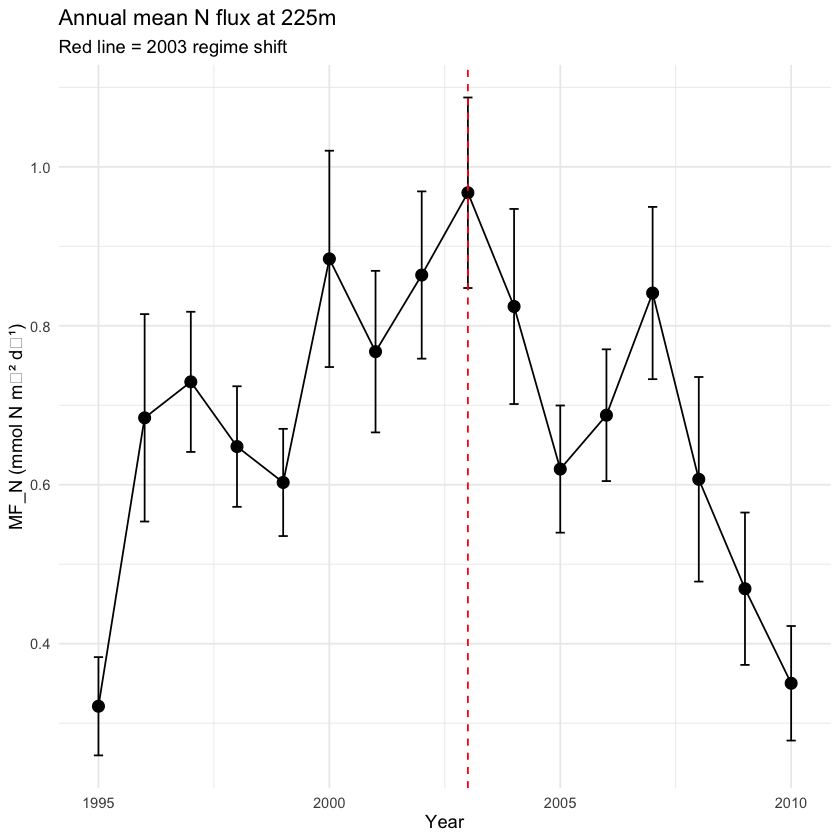

In [12]:
# =============================================================================
# DETAILED TEMPORAL ANALYSIS
# =============================================================================

# Annual means
annual_225 <- trap_shallow %>%
  filter(depth_trap == 225) %>%
  mutate(year = year(date)) %>%
  group_by(year) %>%
  summarise(
    n = sum(!is.na(MF_N_mmol)),
    mean_flux = mean(MF_N_mmol, na.rm = TRUE),
    sd_flux = sd(MF_N_mmol, na.rm = TRUE),
    .groups = "drop"
  )

cat("\n=== Annual 225m flux ===\n")
print(annual_225, n = 20)

# Plot annual trend
ggplot(annual_225, aes(x = year, y = mean_flux)) +
  geom_point(size = 3) +
  geom_line() +
  geom_errorbar(aes(ymin = mean_flux - sd_flux/sqrt(n), 
                    ymax = mean_flux + sd_flux/sqrt(n)), width = 0.2) +
  geom_vline(xintercept = 2003, linetype = "dashed", color = "red") +
  labs(x = "Year", y = "MF_N (mmol N m⁻² d⁻¹)", 
       title = "Annual mean N flux at 225m",
       subtitle = "Red line = 2003 regime shift") +
  theme_minimal()

# Seasonal pattern (all years pooled)
seasonal_225 <- trap_shallow %>%
  filter(depth_trap == 225) %>%
  mutate(month = month(date)) %>%
  group_by(month) %>%
  summarise(
    n = sum(!is.na(MF_N_mmol)),
    mean_flux = mean(MF_N_mmol, na.rm = TRUE),
    sd_flux = sd(MF_N_mmol, na.rm = TRUE),
    .groups = "drop"
  )

cat("\n=== Seasonal 225m flux (all years) ===\n")
print(seasonal_225)

# Compare seasonal pattern early vs late
seasonal_by_period <- trap_shallow %>%
  filter(depth_trap == 225) %>%
  mutate(
    month = month(date),
    period = ifelse(date < as.Date("2003-11-01"), "early", "late")
  ) %>%
  group_by(period, month) %>%
  summarise(mean_flux = mean(MF_N_mmol, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = period, values_from = mean_flux)

cat("\n=== Seasonal pattern: early vs late ===\n")
print(seasonal_by_period)

In [13]:
# =============================================================================
# METRICS FOR MODEL COMPARISON
# =============================================================================

library(tidyverse)

# --- Load your processed data (assuming trap_shallow exists from your script) ---

# =============================================================================
# 1. CLIMATOLOGICAL MEAN FLUX AT 225m (your reference depth)
# =============================================================================

# Monthly climatology for seasonal comparison
clim_225 <- trap_shallow %>%
  filter(depth_trap == 225, !is.na(MF_N_mmol)) %>%
  mutate(month = as.numeric(format(date, "%m"))) %>%
  group_by(month) %>%
  summarise(
    MF_N_mean = mean(MF_N_mmol, na.rm = TRUE),
    MF_N_sd = sd(MF_N_mmol, na.rm = TRUE),
    MF_N_se = sd(MF_N_mmol, na.rm = TRUE) / sqrt(n()),
    n = n(),
    .groups = "drop"
  )

# Annual mean
annual_mean_225 <- trap_shallow %>%
  filter(depth_trap == 225, !is.na(MF_N_mmol)) %>%
  summarise(
    mean_flux = mean(MF_N_mmol),      # mmol N m-2 d-1
    sd_flux = sd(MF_N_mmol),
    median_flux = median(MF_N_mmol),
    q25 = quantile(MF_N_mmol, 0.25),
    q75 = quantile(MF_N_mmol, 0.75)
  )

cat("=== 225m Trap Annual Statistics (mmol N m-2 d-1) ===\n")
print(annual_mean_225)

# =============================================================================
# 2. BACK-CALCULATE EXPORT FLUX AT 50m USING MARTIN CURVE
# =============================================================================

martin_b <- 0.858           # canonical exponent
z_model <- 50               # your model's export depth
z_trap <- 225               # reference trap depth

# Correction factor to estimate F(50m) from F(225m)
correction_factor <- (z_trap / z_model)^martin_b
cat(sprintf("\nMartin correction factor (225m -> 50m): %.2f\n", correction_factor))

# Estimated export at 50m
export_50m_estimate <- annual_mean_225$mean_flux * correction_factor
cat(sprintf("Estimated F(50m): %.3f mmol N m-2 d-1\n", export_50m_estimate))
cat(sprintf("                = %.3f mmol N m-2 d-1 * %.2f\n", 
            annual_mean_225$mean_flux, correction_factor))

# =============================================================================
# 3. DEFINE MODEL COMPARISON METRIC
# =============================================================================

# Your model should produce:
#   F_model(50m) = [Detritus_N] * w_sink
#
# Compare to: export_50m_estimate ± uncertainty

# Propagate uncertainty through Martin correction
export_50m_sd <- annual_mean_225$sd_flux * correction_factor

model_target <- list(
  depth_m = z_model,
  F_N_mean = export_50m_estimate,        # mmol N m-2 d-1
  F_N_sd = export_50m_sd,
  F_N_lower = export_50m_estimate - 1.96 * export_50m_sd / sqrt(297),
  F_N_upper = export_50m_estimate + 1.96 * export_50m_sd / sqrt(297),
  reference_trap = "225m",
  martin_b = martin_b
)

cat("\n=== MODEL TARGET METRIC ===\n")
cat(sprintf("Export flux at %dm: %.3f ± %.3f mmol N m-2 d-1\n", 
            model_target$depth_m, model_target$F_N_mean, model_target$F_N_sd))
cat(sprintf("95%% CI: [%.3f, %.3f]\n", model_target$F_N_lower, model_target$F_N_upper))

# =============================================================================
# 4. ALTERNATIVE: FIT MARTIN EXPONENT FROM MULTI-DEPTH DATA
# =============================================================================

# Use all trap depths to estimate site-specific Martin b
flux_by_depth <- trap_shallow %>%
  bind_rows(
    ds %>%
      filter(depth_trap %in% c(410, 810, 1210)) %>%
      mutate(MF_N_mmol = MF_N * 1000 / 14.007) %>%
      select(date, depth_trap, MF_N_mmol)
  ) %>%
  filter(!is.na(MF_N_mmol)) %>%
  group_by(depth_trap) %>%
  summarise(
    mean_flux = mean(MF_N_mmol, na.rm = TRUE),
    log_flux = log(mean(MF_N_mmol, na.rm = TRUE)),
    log_depth = log(depth_trap[1]),
    .groups = "drop"
  )

# Fit Martin curve: log(F) = log(F0) - b*log(z)
# Using 225m as reference (exclude anomalous 152m)
flux_for_fit <- flux_by_depth %>% filter(depth_trap >= 225)

martin_fit <- lm(log_flux ~ log_depth, data = flux_for_fit)
fitted_b <- -coef(martin_fit)[2]

cat(sprintf("\n=== FITTED MARTIN EXPONENT ===\n"))
cat(sprintf("Site-specific b = %.3f (vs canonical 0.858)\n", fitted_b))

# =============================================================================
# 5. SEASONAL PATTERN FOR MODEL VALIDATION
# =============================================================================

cat("\n=== MONTHLY CLIMATOLOGY AT 225m (mmol N m-2 d-1) ===\n")
print(clim_225)

# This gives you a seasonal target to compare model output against

=== 225m Trap Annual Statistics (mmol N m-2 d-1) ===
  mean_flux   sd_flux median_flux       q25       q75
1  0.710323 0.4786346    0.571143 0.3569644 0.9281074

Martin correction factor (225m -> 50m): 3.63
Estimated F(50m): 2.582 mmol N m-2 d-1
                = 0.710 mmol N m-2 d-1 * 3.63

=== MODEL TARGET METRIC ===
Export flux at 50m: 2.582 ± 1.740 mmol N m-2 d-1
95% CI: [2.384, 2.780]

=== FITTED MARTIN EXPONENT ===
Site-specific b = 0.511 (vs canonical 0.858)

=== MONTHLY CLIMATOLOGY AT 225m (mmol N m-2 d-1) ===
# A tibble: 12 × 5
   month MF_N_mean MF_N_sd MF_N_se     n
   <dbl>     <dbl>   <dbl>   <dbl> <int>
 1     1     0.614   0.350  0.0575    37
 2     2     0.699   0.559  0.114     24
 3     3     0.695   0.543  0.124     19
 4     4     0.520   0.367  0.0980    14
 5     5     1.53    0.614  0.141     19
 6     6     0.827   0.336  0.0686    24
 7     7     0.757   0.347  0.0656    28
 8     8     0.577   0.366  0.0747    24
 9     9     0.571   0.382  0.0814    22
10    